In [1]:
import os
import json
import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pickle
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


In [2]:
with open("data/processed/config.json") as f:
    config = json.load(f)

STATION_ORDER = config["station_order"]
FEAT_COLS     = config["feat_cols"]
INPUT_LEN     = config["input_len"]
HORIZON       = config["horizon"]
N             = len(STATION_ORDER)
F_DIM         = len(FEAT_COLS)

A_norm   = np.load("data/processed/adj_norm.npy").astype(np.float32)
A_tensor = torch.tensor(A_norm).to(DEVICE)

X_train = np.load("data/processed/X_train.npy")
y_train = np.load("data/processed/y_train.npy")
X_val   = np.load("data/processed/X_val.npy")
y_val   = np.load("data/processed/y_val.npy")
X_test  = np.load("data/processed/X_test.npy")
y_test  = np.load("data/processed/y_test.npy")

def reconstruct_dates(X, split_start_str, input_len):
    """Approximate forecast-start dates from split start + window offset."""
    start = datetime.date.fromisoformat(split_start_str)
    # First valid window starts at input_len days after split start
    return [start + datetime.timedelta(days=input_len + i)
            for i in range(len(X))]

dates_tr = reconstruct_dates(X_train, "1993-01-01", INPUT_LEN)
dates_va = reconstruct_dates(X_val,   "2001-01-01", INPUT_LEN)
dates_te = reconstruct_dates(X_test,  "2002-01-01", INPUT_LEN)

print(f"X_train {X_train.shape}  dates_tr[0]={dates_tr[0]}  dates_tr[-1]={dates_tr[-1]}")
print(f"X_val   {X_val.shape}    dates_va[0]={dates_va[0]}")
print(f"X_test  {X_test.shape}   dates_te[0]={dates_te[0]}")

X_train (2773, 14, 10, 10)  dates_tr[0]=1993-01-15  dates_tr[-1]=2000-08-18
X_val   (316, 14, 10, 10)    dates_va[0]=2001-01-15
X_test  (674, 14, 10, 10)   dates_te[0]=2002-01-15


In [3]:
class DischargeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_ds = DischargeDataset(X_train, y_train)
val_ds   = DischargeDataset(X_val,   y_val)
test_ds  = DischargeDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 86
Val batches   : 10
Test batches  : 22


In [4]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, H, A):
        AH = torch.matmul(A, H)
        return F.relu(self.W(AH))


class STGNN(nn.Module):
    def __init__(self, f_dim, hidden_dim, gcn_dim, horizon, n_nodes,
                 n_gru_layers=1, dropout=0.1, use_graph=True):
        super().__init__()
        self.horizon   = horizon
        self.use_graph = use_graph

        self.gru = nn.GRU(
            input_size  = f_dim,
            hidden_size = hidden_dim,
            num_layers  = n_gru_layers,
            batch_first = True,
            dropout     = dropout if n_gru_layers > 1 else 0.0,
        )
        self.gcn     = GCNLayer(hidden_dim, gcn_dim)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(gcn_dim, horizon)

    def forward(self, X, A):
        batch, T, N_nodes, F_dim = X.shape
        X_reshaped = X.permute(0, 2, 1, 3).reshape(batch * N_nodes, T, F_dim)
        _, h_n = self.gru(X_reshaped)
        h = h_n[-1]
        H = h.reshape(batch, N_nodes, -1)

        if self.use_graph:
            H = self.gcn(H, A)
        else:
            H = torch.relu(self.gcn.W(H))

        H   = self.dropout(H)
        out = self.decoder(H)
        return out.permute(0, 2, 1)


def masked_mse(pred, target):
    mask = ~torch.isnan(target)
    return F.mse_loss(pred[mask], target[mask])


# Hyperparameters
HIDDEN_DIM   = 64
GCN_DIM      = 64
N_GRU_LAYERS = 2
DROPOUT      = 0.1
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 100
PATIENCE     = 15
LR_PATIENCE  = 7
LR_FACTOR    = 0.5

print("Model classes and hyperparameters defined.")

Model classes and hyperparameters defined.


In [5]:
def train_model(model, train_loader, val_loader, A,
                max_epochs, patience, lr, weight_decay,
                lr_patience, lr_factor, model_name):
    """
    Full training loop with early stopping and LR scheduling.
    Returns history dict and path to best checkpoint.
    """
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=lr_factor,
        patience=lr_patience,           # verbose removed — not supported in PyTorch 2.x
    )

    os.makedirs("data/processed", exist_ok=True)
    ckpt_path = f"data/processed/best_{model_name}.pt"

    history = {"train_loss": [], "val_loss": [], "lr": []}
    best_val   = float("inf")
    no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb, A)
            loss = masked_mse(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb, A)
                val_losses.append(masked_mse(pred, yb).item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        scheduler.step(val_loss)

        # ── Early stopping ────────────────────────────────────────────────────
        if val_loss < best_val - 1e-6:
            best_val   = val_loss
            no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{model_name}] epoch {epoch:3d}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={current_lr:.2e}  best={best_val:.4f}")

        if no_improve >= patience:
            print(f"  [{model_name}] Early stop at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"  [{model_name}] Best val loss: {best_val:.4f}  "
          f"saved → {ckpt_path}")
    return history, ckpt_path

In [6]:
torch.manual_seed(42)
np.random.seed(42)

model_stgnn = STGNN(
    f_dim=F_DIM, hidden_dim=HIDDEN_DIM, gcn_dim=GCN_DIM,
    horizon=HORIZON, n_nodes=N, n_gru_layers=N_GRU_LAYERS,
    dropout=DROPOUT, use_graph=True,
).to(DEVICE)

print("=== Training STGNN (with graph) ===")
hist_stgnn, ckpt_stgnn = train_model(
    model_stgnn, train_loader, val_loader, A_tensor,
    max_epochs=MAX_EPOCHS, patience=PATIENCE,
    lr=LR, weight_decay=WEIGHT_DECAY,
    lr_patience=LR_PATIENCE, lr_factor=LR_FACTOR,
    model_name="stgnn",
)

=== Training STGNN (with graph) ===
  [stgnn] epoch   1  train=0.0254  val=0.0113  lr=1.00e-03  best=0.0113
  [stgnn] epoch  10  train=0.0104  val=0.0099  lr=1.00e-03  best=0.0099
  [stgnn] epoch  20  train=0.0100  val=0.0096  lr=1.00e-03  best=0.0096
  [stgnn] epoch  30  train=0.0098  val=0.0097  lr=1.00e-03  best=0.0096
  [stgnn] epoch  40  train=0.0097  val=0.0098  lr=1.00e-03  best=0.0095
  [stgnn] epoch  50  train=0.0096  val=0.0096  lr=5.00e-04  best=0.0095
  [stgnn] epoch  60  train=0.0096  val=0.0095  lr=2.50e-04  best=0.0095
  [stgnn] Early stop at epoch 61 (no improvement for 15 epochs)
  [stgnn] Best val loss: 0.0095  saved → data/processed/best_stgnn.pt


In [7]:
torch.manual_seed(42)
np.random.seed(42)

model_nograph = STGNN(
    f_dim=F_DIM, hidden_dim=HIDDEN_DIM, gcn_dim=GCN_DIM,
    horizon=HORIZON, n_nodes=N, n_gru_layers=N_GRU_LAYERS,
    dropout=DROPOUT, use_graph=False,
).to(DEVICE)

print("=== Training No-Graph ablation ===")
hist_nograph, ckpt_nograph = train_model(
    model_nograph, train_loader, val_loader, A_tensor,
    max_epochs=MAX_EPOCHS, patience=PATIENCE,
    lr=LR, weight_decay=WEIGHT_DECAY,
    lr_patience=LR_PATIENCE, lr_factor=LR_FACTOR,
    model_name="nograph",
)

=== Training No-Graph ablation ===
  [nograph] epoch   1  train=0.0253  val=0.0112  lr=1.00e-03  best=0.0112
  [nograph] epoch  10  train=0.0103  val=0.0098  lr=1.00e-03  best=0.0098
  [nograph] epoch  20  train=0.0099  val=0.0095  lr=1.00e-03  best=0.0095
  [nograph] epoch  30  train=0.0097  val=0.0096  lr=1.00e-03  best=0.0095
  [nograph] epoch  40  train=0.0096  val=0.0096  lr=1.00e-03  best=0.0094
  [nograph] epoch  50  train=0.0095  val=0.0095  lr=5.00e-04  best=0.0094
  [nograph] Early stop at epoch 58 (no improvement for 15 epochs)
  [nograph] Best val loss: 0.0094  saved → data/processed/best_nograph.pt


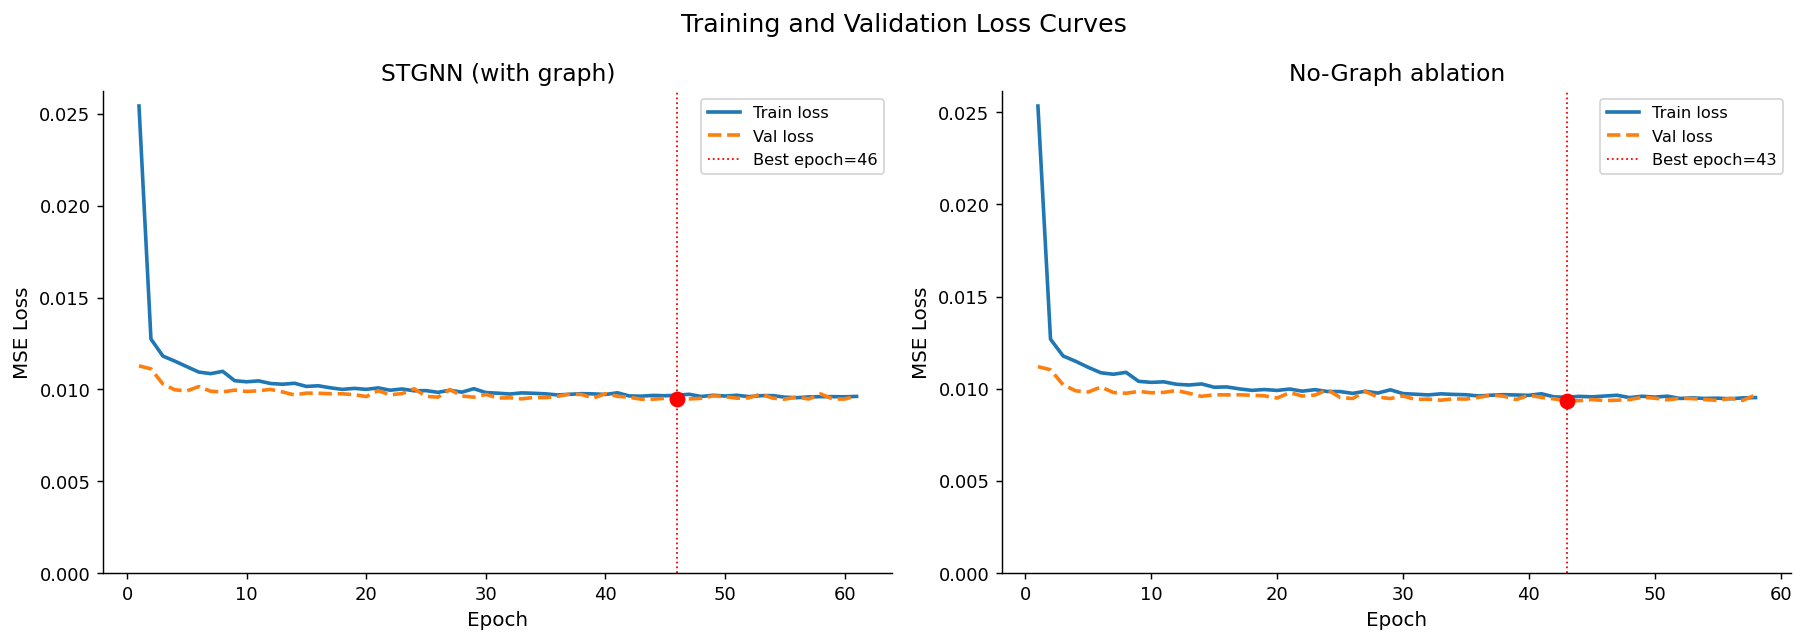


Summary:
  STGNN    best val MSE : 0.0095  @ epoch 46
  NoGraph  best val MSE : 0.0094  @ epoch 43


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in zip(
    axes,
    [hist_stgnn, hist_nograph],
    ["STGNN (with graph)", "No-Graph ablation"],
):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], lw=2, label="Train loss")
    ax.plot(epochs, hist["val_loss"],   lw=2, label="Val loss",
            linestyle="--")

    best_epoch = int(np.argmin(hist["val_loss"])) + 1
    best_val   = min(hist["val_loss"])
    ax.axvline(best_epoch, color="red", lw=1, linestyle=":",
               label=f"Best epoch={best_epoch}")
    ax.scatter([best_epoch], [best_val], color="red", zorder=5, s=60)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

fig.suptitle("Training and Validation Loss Curves", fontsize=14)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  STGNN    best val MSE : {min(hist_stgnn['val_loss']):.4f}  "
      f"@ epoch {np.argmin(hist_stgnn['val_loss'])+1}")
print(f"  NoGraph  best val MSE : {min(hist_nograph['val_loss']):.4f}  "
      f"@ epoch {np.argmin(hist_nograph['val_loss'])+1}")

In [9]:
last_obs   = X_test[:, -1, :, 0]                        # (samples, N)
pred_persistence = np.stack([last_obs] * HORIZON, axis=1)  # (samples, H, N)
print(f"Persistence predictions : {pred_persistence.shape}")

doy_mean = {}
for i, date in enumerate(dates_tr):
    for h in range(HORIZON):
        fdate = date + datetime.timedelta(days=h)
        doy   = fdate.timetuple().tm_yday
        if doy not in doy_mean:
            doy_mean[doy] = []
        doy_mean[doy].append(y_train[i, h, :])   # (N,)

doy_mean = {
    doy: np.mean(np.stack(vals), axis=0)
    for doy, vals in doy_mean.items()
}
global_mean = np.mean(np.stack(list(doy_mean.values())), axis=0)

pred_climatology = []
for date in dates_te:
    horizon_pred = []
    for h in range(HORIZON):
        fdate = date + datetime.timedelta(days=h)
        doy   = fdate.timetuple().tm_yday
        horizon_pred.append(doy_mean.get(doy, global_mean))
    pred_climatology.append(np.stack(horizon_pred))   # (H, N)
pred_climatology = np.stack(pred_climatology)          # (samples, H, N)
print(f"Climatology predictions : {pred_climatology.shape}")

Persistence predictions : (674, 7, 10)
Climatology predictions : (674, 7, 10)


In [10]:
def predict_all(model, loader, A, device):
    """Run model over full DataLoader, return (samples, horizon, N) array."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb, A)
            preds.append(pred.cpu().numpy())
            targets.append(yb.numpy())
    return np.concatenate(preds, axis=0), np.concatenate(targets, axis=0)


# Load best checkpoints
model_stgnn.load_state_dict(torch.load(ckpt_stgnn,
                            map_location=DEVICE, weights_only=True))
model_nograph.load_state_dict(torch.load(ckpt_nograph,
                              map_location=DEVICE, weights_only=True))

pred_stgnn,   y_true = predict_all(model_stgnn,   test_loader, A_tensor, DEVICE)
pred_nograph, _      = predict_all(model_nograph,  test_loader, A_tensor, DEVICE)

print(f"pred_stgnn   : {pred_stgnn.shape}")
print(f"pred_nograph : {pred_nograph.shape}")
print(f"y_true       : {y_true.shape}")

pred_stgnn   : (674, 7, 10)
pred_nograph : (674, 7, 10)
y_true       : (674, 7, 10)


In [11]:
np.save("data/processed/pred_stgnn.npy",       pred_stgnn)
np.save("data/processed/pred_nograph.npy",      pred_nograph)
np.save("data/processed/pred_persistence.npy",  pred_persistence)
np.save("data/processed/pred_climatology.npy",  pred_climatology)
np.save("data/processed/y_true_test.npy",       y_true)

print("Saved predictions:")
for name in ["pred_stgnn", "pred_nograph",
             "pred_persistence", "pred_climatology", "y_true_test"]:
    arr = np.load(f"data/processed/{name}.npy")
    print(f"  {name}.npy  {arr.shape}")

Saved predictions:
  pred_stgnn.npy  (674, 7, 10)
  pred_nograph.npy  (674, 7, 10)
  pred_persistence.npy  (674, 7, 10)
  pred_climatology.npy  (674, 7, 10)
  y_true_test.npy  (674, 7, 10)


In [12]:
def mse(pred, target):
    return float(np.mean((pred - target) ** 2))

print("Quick test MSE (scaled log space) — full comparison in 06_evaluate:")
print(f"  Persistence  : {mse(pred_persistence, y_true):.4f}")
print(f"  Climatology  : {mse(pred_climatology, y_true):.4f}")
print(f"  No-Graph     : {mse(pred_nograph,     y_true):.4f}")
print(f"  STGNN        : {mse(pred_stgnn,       y_true):.4f}")
print()
print("Expected ranking: STGNN < No-Graph < Persistence < Climatology")
print("Full per-station breakdown and m³/s metrics → 06_evaluate.ipynb")

Quick test MSE (scaled log space) — full comparison in 06_evaluate:
  Persistence  : 0.0111
  Climatology  : 0.0159
  No-Graph     : 0.0083
  STGNN        : 0.0085

Expected ranking: STGNN < No-Graph < Persistence < Climatology
Full per-station breakdown and m³/s metrics → 06_evaluate.ipynb
